<a href="https://colab.research.google.com/github/Asvelasquez/PROCESAMIENTO-DE-LENGUAJE-NATURAL/blob/main/01_texto_a_embeddings_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformacion de texto en representaciones vectoriales con Word2Vec

En el siguiente ejercicio se busca transformar textos en español en representaciones numericas densas mediante Word2Vec y comparar el resultado con TF IDF.

TF IDF asigna una columna propia a cada palabra, por lo que dos sinonimos resultan distintos entre si como dos palabras sin ninguna relacion.

Word2Vec aprende un vector corto para cada palabra a partir de los contextos en que aparece y en ese espacio los sinonimos quedan cerca.

## 1. Librerias



In [2]:
import re
import random
import unicodedata

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

## 2. corpus

para que sea eficiente Word2Vec necesita repeticion por lo cual se generan 900 documentos combinando plantillas


In [3]:
SINONIMOS = {
    "ATAQUE": ["fraude", "estafa", "engano", "trampa"],
    "DATO": ["credenciales", "contrasenas", "claves", "informacion"],
    "FALLO": ["vulnerabilidad", "falla", "debilidad", "descuido"],
    "ACTOR": ["atacante", "delincuente", "intruso", "adversario"],
    "SISTEMA": ["servidor", "equipo", "sistema", "portal"],
    "GRAVE": ["critica", "grave", "severa", "peligroso"],
    "DETECTAR": ["detecto", "identifico", "observo", "encontro"],
}

PLANTILLAS = {
    "phishing": [
        "campana de phishing por correo que busca robar DATO de los clientes",
        "el ACTOR envia mensajes falsos de phishing para obtener DATO mediante ATAQUE",
        "portal clonado del banco disenado para capturar DATO de usuarios desprevenidos",
        "se DETECTAR una oleada de ATAQUE por mensajeria dirigida a los empleados",
        "el equipo de respuesta DETECTAR correos de phishing que suplantan al proveedor",
        "sitio fraudulento que imita el SISTEMA corporativo para capturar DATO",
    ],
    "ransomware": [
        "el ACTOR desplego ransomware y cifro los archivos del SISTEMA",
        "incidente de ransomware que dejo el SISTEMA fuera de servicio durante horas",
        "secuestro de informacion en el SISTEMA con rescate exigido en criptomonedas",
        "el cifrador se propago por la red interna afectando cada SISTEMA conectado",
        "se DETECTAR actividad de ransomware con extorsion doble y filtracion de datos",
        "las copias de respaldo permitieron restaurar el SISTEMA tras el cifrado",
    ],
    "vulnerabilidad": [
        "se publico una FALLO GRAVE que afecta al SISTEMA sin actualizar",
        "el parche corrige una FALLO explotable de forma remota en el SISTEMA",
        "FALLO de severidad GRAVE detectada durante la auditoria del SISTEMA",
        "el proveedor DETECTAR una FALLO en la biblioteca que utiliza el SISTEMA",
        "existe codigo de explotacion publico para esta FALLO GRAVE del SISTEMA",
        "la actualizacion resuelve varias FALLO acumuladas en el SISTEMA expuesto",
    ],
}

DOCUMENTOS_POR_CATEGORIA = 300


def expandir(plantilla):
    """reemplazar cada ranura en mayusculas por un sinonimo al azar"""
    texto = plantilla
    for ranura, opciones in SINONIMOS.items():
        while ranura in texto:
            texto = texto.replace(ranura, random.choice(opciones), 1)
    return texto


documentos, categorias = [], []
for categoria, plantillas in PLANTILLAS.items():
    for _ in range(DOCUMENTOS_POR_CATEGORIA):
        documentos.append(expandir(random.choice(plantillas)))
        categorias.append(categoria)

categorias = np.array(categorias)

print(f"documentos generados: {len(documentos)}")
print(f"categorias: {sorted(set(categorias))}\n")
for i in [0, 250, 500]:
    print(f"[{categorias[i]:15s}] {documentos[i]}")

documentos generados: 900
categorias: [np.str_('phishing'), np.str_('ransomware'), np.str_('vulnerabilidad')]

[phishing       ] sitio fraudulento que imita el servidor corporativo para capturar credenciales
[phishing       ] portal clonado del banco disenado para capturar contrasenas de usuarios desprevenidos
[ransomware     ] el adversario desplego ransomware y cifro los archivos del servidor


## 3. Preprocesamiento

minusculas, sin tildes, palabras de 3 o mas letras

In [4]:
STOPWORDS = {
    "el", "la", "los", "las", "un", "una", "unos", "unas", "de", "del", "y", "o",
    "en", "por", "para", "con", "sin", "al", "que", "se", "su", "sus", "a", "es",
}


def normalizar(texto):
    """minusculas y sin tildes"""
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in texto if not unicodedata.combining(c))


def tokenizar(texto):
    """convertir la cadena en una lista de palabras utiles"""
    tokens = re.findall(r"[a-zñ]+", normalizar(texto))
    return [t for t in tokens if len(t) >= 3 and t not in STOPWORDS]


corpus_tokens = [tokenizar(doc) for doc in documentos]
documentos_procesados = [" ".join(tokens) for tokens in corpus_tokens]

total_tokens = sum(len(t) for t in corpus_tokens)
vocabulario_corpus = sorted({t for doc in corpus_tokens for t in doc})

print(f"palabras distintas: {len(vocabulario_corpus)}")
print(f"longitud media:     {total_tokens / len(corpus_tokens):.1f} tokens por documento")
print(f"\nejemplo: {corpus_tokens[0]}")

palabras distintas: 111
longitud media:     7.1 tokens por documento

ejemplo: ['sitio', 'fraudulento', 'imita', 'servidor', 'corporativo', 'capturar', 'credenciales']


## 4. comparacion con TF-IDF



In [5]:
vectorizador = TfidfVectorizer(lowercase=False, norm="l2")
X_tfidf = vectorizador.fit_transform(documentos_procesados)
terminos = vectorizador.get_feature_names_out()

celdas_vacias = 100 * (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print(f"matriz TF-IDF: {X_tfidf.shape[0]} documentos x {X_tfidf.shape[1]} terminos")
print(f"celdas en cero: {celdas_vacias:.1f} % representacion")

matriz TF-IDF: 900 documentos x 111 terminos
celdas en cero: 93.6 % representacion


El vector de una palabra en TF IDF es su columna, es decir en que documentos aparece, el coseno multiplica dos columnas posicion por posicion entonces si  dos palabras nunca coinciden en un mismo documento el resultado es cero

In [6]:
M_terminos = X_tfidf.T.toarray()
indice_termino = {t: i for i, t in enumerate(terminos)}


def similitud_tfidf(palabra_a, palabra_b):
    a = M_terminos[indice_termino[palabra_a]].reshape(1, -1)
    b = M_terminos[indice_termino[palabra_b]].reshape(1, -1)
    return float(cosine_similarity(a, b)[0][0])


PARES = [
    ("fraude", "estafa"),
    ("credenciales", "contrasenas"),
    ("atacante", "delincuente"),
    ("fraude", "servidor"),
]

print("similitud del coseno entre terminos en TF-IDF\n")
for a, b in PARES:
    print(f"  {a:>13} ~ {b:<13} {similitud_tfidf(a, b):.3f}")

print("\nlos cuatro valen 0 TF-IDF no distingue un par de sinonimos de un par sin ninguna relacion")

similitud del coseno entre terminos en TF-IDF

         fraude ~ estafa        0.000
   credenciales ~ contrasenas   0.000
       atacante ~ delincuente   0.000
         fraude ~ servidor      0.000

los cuatro valen 0 TF-IDF no distingue un par de sinonimos de un par sin ninguna relacion


## 5. Word2Vec con Keras

se usan dos capas embedding, la de la palabra central es el resultado que nos interesa, la de contexto se descarta al terminar, al final los vectores se guardan en una clase para poder consultarlos

In [7]:
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import skipgrams

DIMENSIONES, VENTANA, NEGATIVOS, EPOCAS = 50, 3, 5, 20
tf.random.set_seed(SEMILLA)

#palabras que aparecen al menos dos veces
frecuencia = Counter(p for doc in corpus_tokens for p in doc)
vocabulario = sorted(p for p, f in frecuencia.items() if f >= 2)
indice = {p: i for i, p in enumerate(vocabulario)}
V = len(vocabulario)

# pares inventados con etiqueta 0
parejas, etiquetas = [], []
for documento in corpus_tokens:
    ids = [indice[p] for p in documento if p in indice]
    pares_doc, etiquetas_doc = skipgrams(ids, V, window_size=VENTANA,
                                         negative_samples=NEGATIVOS, shuffle=True, seed=SEMILLA)
    parejas += pares_doc
    etiquetas += etiquetas_doc

parejas = np.array(parejas)
centros, contextos = parejas[:, 0], parejas[:, 1]
etiquetas = np.array(etiquetas)

print(f"vocabulario: {V} palabras")
print(f"pares de entrenamiento: {len(parejas)}")

vocabulario: 111 palabras
pares de entrenamiento: 162096


### red

In [8]:
entrada_centro = keras.Input(shape=(1,))
entrada_contexto = keras.Input(shape=(1,))

vectores = layers.Embedding(V, DIMENSIONES, name="vectores")   # el resultado
contexto = layers.Embedding(V, DIMENSIONES)                    # se descarta

producto = layers.Dot(axes=2)([vectores(entrada_centro), contexto(entrada_contexto)])
salida = layers.Activation("sigmoid")(layers.Flatten()(producto))

red = keras.Model([entrada_centro, entrada_contexto], salida)
red.compile(optimizer="adam", loss="binary_crossentropy")
print(f"parametros entrenables: {red.count_params()}")


parametros entrenables: 11100


## 6. entrenamiento

In [9]:
historia = red.fit([centros, contextos], etiquetas,
                   epochs=EPOCAS, batch_size=256, verbose=2)


class Vectores:
    """consulta vectores aprendidos por la red"""

    def __init__(self, matriz, vocabulario, historial):
        self.dimensiones = matriz.shape[1]
        self.vocabulario = vocabulario
        self.indice = {p: i for i, p in enumerate(vocabulario)}
        self.historial = historial
        self.W_norm = matriz / (np.linalg.norm(matriz, axis=1, keepdims=True) + 1e-10)

    def __contains__(self, palabra):
        return palabra in self.indice

    def vector(self, palabra):
        if palabra not in self.indice:
            raise KeyError(f"'{palabra}' no esta en el vocabulario")
        return self.W_norm[self.indice[palabra]]

    def similitud(self, a, b):
        return float(self.vector(a) @ self.vector(b))

    def similares(self, palabra, n=5):
        puntuaciones = self.W_norm @ self.vector(palabra)
        return [(self.vocabulario[i], float(puntuaciones[i]))
                for i in np.argsort(-puntuaciones)
                if self.vocabulario[i] != palabra][:n]


modelo = Vectores(red.get_layer("vectores").get_weights()[0],
                  vocabulario, historia.history["loss"])

Epoch 1/20
634/634 - 5s - 8ms/step - loss: 0.4288
Epoch 2/20
634/634 - 3s - 4ms/step - loss: 0.2451
Epoch 3/20
634/634 - 1s - 2ms/step - loss: 0.1808
Epoch 4/20
634/634 - 1s - 2ms/step - loss: 0.1566
Epoch 5/20
634/634 - 1s - 2ms/step - loss: 0.1448
Epoch 6/20
634/634 - 3s - 4ms/step - loss: 0.1379
Epoch 7/20
634/634 - 3s - 4ms/step - loss: 0.1336
Epoch 8/20
634/634 - 2s - 3ms/step - loss: 0.1306
Epoch 9/20
634/634 - 2s - 3ms/step - loss: 0.1286
Epoch 10/20
634/634 - 1s - 2ms/step - loss: 0.1272
Epoch 11/20
634/634 - 1s - 2ms/step - loss: 0.1261
Epoch 12/20
634/634 - 1s - 2ms/step - loss: 0.1253
Epoch 13/20
634/634 - 1s - 2ms/step - loss: 0.1247
Epoch 14/20
634/634 - 1s - 2ms/step - loss: 0.1242
Epoch 15/20
634/634 - 1s - 2ms/step - loss: 0.1238
Epoch 16/20
634/634 - 3s - 6ms/step - loss: 0.1235
Epoch 17/20
634/634 - 2s - 2ms/step - loss: 0.1232
Epoch 18/20
634/634 - 1s - 2ms/step - loss: 0.1230
Epoch 19/20
634/634 - 1s - 2ms/step - loss: 0.1228
Epoch 20/20
634/634 - 1s - 2ms/step - lo

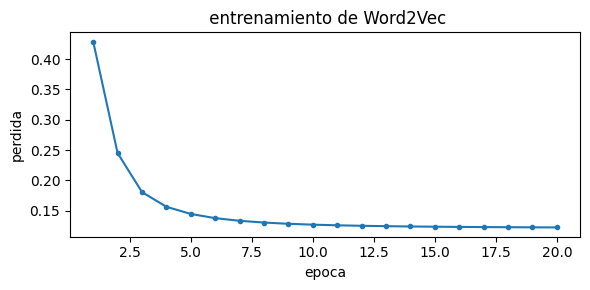

perdida inicial: 0.4288
perdida final:   0.1226


In [10]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(modelo.historial) + 1), modelo.historial, marker="o", ms=3)
plt.xlabel("epoca")
plt.ylabel("perdida")
plt.title(" entrenamiento de Word2Vec")
plt.tight_layout()
plt.show()

print(f"perdida inicial: {modelo.historial[0]:.4f}")
print(f"perdida final:   {modelo.historial[-1]:.4f}")

In [11]:
print("palabras mas proximas en el espacio aprendido\n")
for palabra in ["fraude", "credenciales", "vulnerabilidad", "servidor", "ransomware"]:
    vecinos = ", ".join(f"{p} ({s:.2f})" for p, s in modelo.similares(palabra, 3))
    print(f"  {palabra:>15} : {vecinos}")

palabras mas proximas en el espacio aprendido

           fraude : estafa (0.98), engano (0.97), trampa (0.95)
     credenciales : contrasenas (0.98), claves (0.96), informacion (0.81)
   vulnerabilidad : descuido (0.97), debilidad (0.96), falla (0.96)
         servidor : sistema (0.95), portal (0.78), equipo (0.74)
       ransomware : cifro (0.71), dejo (0.60), archivos (0.60)


## 7. comparacion con la seccion 4

Los mismos cuatro pares de terminos, ahora con las dos representaciones.

In [12]:
print(f"{'par de terminos':<32}{'TF-IDF':>10}{'Word2Vec':>12}   sinonimos")
print("-" * 68)
comparativa = []
for a, b in PARES:
    s_tfidf = similitud_tfidf(a, b)
    s_w2v = modelo.similitud(a, b)
    son_sinonimos = "si" if (a, b) != ("fraude", "servidor") else "NO"
    comparativa.append((f"{a} ~ {b}", s_tfidf, s_w2v, son_sinonimos))
    print(f"{a + ' - ' + b:<32}{s_tfidf:>10.3f}{s_w2v:>12.3f}   {son_sinonimos}")

par de terminos                     TF-IDF    Word2Vec   sinonimos
--------------------------------------------------------------------
fraude - estafa                      0.000       0.975   si
credenciales - contrasenas           0.000       0.981   si
atacante - delincuente               0.000       0.990   si
fraude - servidor                    0.000       0.212   NO


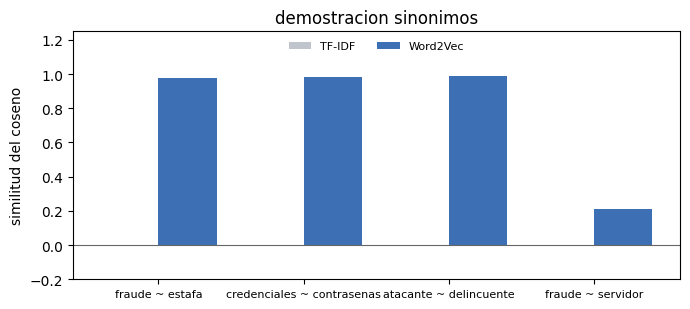

In [13]:
etiquetas_pares = [c[0] for c in comparativa]
x = np.arange(len(comparativa))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(x - 0.2, [c[1] for c in comparativa], 0.4, label="TF-IDF", color="#c0c4cc")
ax.bar(x + 0.2, [c[2] for c in comparativa], 0.4, label="Word2Vec", color="#3d6fb4")
ax.axhline(0, color="#666", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas_pares, fontsize=8)
ax.set_ylabel("similitud del coseno")
ax.set_ylim(-0.2, 1.25)
ax.set_title("demostracion sinonimos")
ax.legend(loc="upper center", ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Vectores de documento y busqueda

Word2Vec da un vector por palabra, pero para buscar hace falta uno por documento, se promedian los vectores de sus palabras, las que no estan en el vocabulario se descartan

In [14]:
def vectorizar_documento(tokens, modelo):
    """promedio normalizado de los vectores de las palabras conocidas"""
    vectores = [modelo.vector(t) for t in tokens if t in modelo]
    if not vectores:
        return np.zeros(modelo.dimensiones)
    promedio = np.mean(vectores, axis=0)
    return promedio / (np.linalg.norm(promedio) + 1e-10)


X_w2v = np.array([vectorizar_documento(tokens, modelo) for tokens in corpus_tokens])

print(f"TF-IDF:   {X_tfidf.shape[1]} dimensiones por documento")
print(f"Word2Vec: {X_w2v.shape[1]} dimensiones por documento")

TF-IDF:   111 dimensiones por documento
Word2Vec: 50 dimensiones por documento


### busqueda

Las consultas usan sinonimos de las palabras que aparecen en los documentos

In [15]:
def buscar(consulta):
    """mejor documento"""
    tokens = tokenizar(consulta)
    desconocidas = [t for t in tokens if t not in modelo]

    similitudes_tfidf = cosine_similarity(
        vectorizador.transform([" ".join(tokens)]), X_tfidf)[0]
    similitudes_w2v = X_w2v @ vectorizar_documento(tokens, modelo)

    i_tf, i_w2 = int(np.argmax(similitudes_tfidf)), int(np.argmax(similitudes_w2v))
    return similitudes_tfidf[i_tf], i_tf, similitudes_w2v[i_w2], i_w2, desconocidas


CONSULTAS = [
    "trampa que roba claves de los clientes",
    "secuestro de archivos con pago exigido",
    "descuido peligroso en el portal sin actualizar",
]

for consulta in CONSULTAS:
    s_tf, i_tf, s_w2, i_w2, desconocidas = buscar(consulta)
    print(f"\nconsulta: {consulta}")
    if desconocidas:
        print(f"  palabras que no estan en el vocabulario: {desconocidas}")
    print(f"  TF-IDF   {s_tf:.3f} | {categorias[i_tf]:15s} | {documentos[i_tf]}")
    print(f"  Word2Vec {s_w2:.3f} | {categorias[i_w2]:15s} | {documentos[i_w2]}")


consulta: trampa que roba claves de los clientes
  palabras que no estan en el vocabulario: ['roba']
  TF-IDF   0.438 | phishing        | el adversario envia mensajes falsos de phishing para obtener claves mediante trampa
  Word2Vec 0.817 | phishing        | campana de phishing por correo que busca robar claves de los clientes

consulta: secuestro de archivos con pago exigido
  palabras que no estan en el vocabulario: ['pago']
  TF-IDF   0.521 | ransomware      | secuestro de informacion en el portal con rescate exigido en criptomonedas
  Word2Vec 0.858 | ransomware      | secuestro de informacion en el sistema con rescate exigido en criptomonedas

consulta: descuido peligroso en el portal sin actualizar
  TF-IDF   0.819 | vulnerabilidad  | se publico una descuido peligroso que afecta al portal sin actualizar
  Word2Vec 0.960 | vulnerabilidad  | se publico una debilidad severa que afecta al portal sin actualizar


## 9. conclusiones


1. TF-IDF es rapido pero su limite es la similitud de 0,000 entre sinonimos
2. Word2Vec ocurre sin supervision, solo vio coocurrencias.
4. se pueden complementar ya que se da la recuperacion rapida por palabras con TF-IDF y despues comparacion por significado con los vectores.


In [16]:
print("resumen ejercicio")
print(f"  documentos                    {len(documentos)}")
print(f"  vocabulario                   {len(vocabulario_corpus)} palabras")
print(f"  dimensiones TF-IDF            {X_tfidf.shape[1]}")
print(f"  dimensiones Word2Vec          {modelo.dimensiones}")
print(f"  perdida final Word2Vec        {modelo.historial[-1]:.4f}")
print(f"  similitud fraude y estafa     TF-IDF {similitud_tfidf('fraude', 'estafa'):.3f}"
      f" - Word2Vec {modelo.similitud('fraude', 'estafa'):.3f}")

resumen ejercicio
  documentos                    900
  vocabulario                   111 palabras
  dimensiones TF-IDF            111
  dimensiones Word2Vec          50
  perdida final Word2Vec        0.1226
  similitud fraude y estafa     TF-IDF 0.000 - Word2Vec 0.975
